# Regressão 01 - tarefa 02 - transformações em X e Y

### 1. Melhorando o ajuste no percentual de gorjetas

a. Vamos partir do modelo feito na última tarefa, o que relaciona ```tip_pct``` e ```net_bill```. Carregue a base, os pacotes e reproduza este modelo aqui.

In [1]:
import pandas as pd
import seaborn as sns
from seaborn import load_dataset

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

In [3]:
tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,net_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.063204,15.98
1,10.34,1.66,Male,No,Sun,Dinner,3,0.191244,8.68
2,21.01,3.50,Male,No,Sun,Dinner,3,0.199886,17.51
3,23.68,3.31,Male,No,Sun,Dinner,2,0.162494,20.37
4,24.59,3.61,Female,No,Sun,Dinner,4,0.172069,20.98


                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     24.31
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           1.52e-06
Time:                        07:46:36   Log-Likelihood:                 108.00
No. Observations:                 244   AIC:                            -212.0
Df Residuals:                     242   BIC:                            -205.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3053      0.023     13.166      0.0

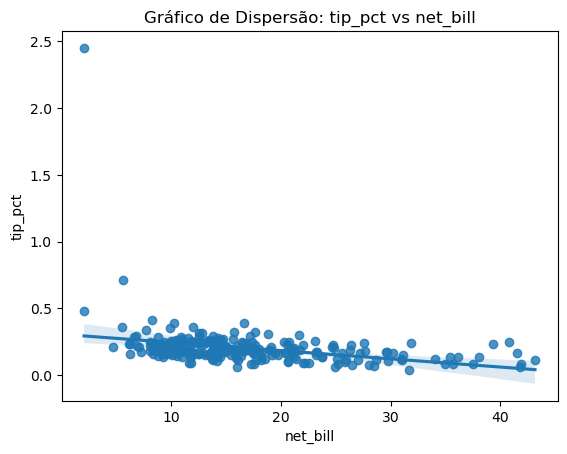

In [5]:
# Ajustando o modelo
reg_pct = smf.ols('tip_pct ~ net_bill', data=tips).fit()
print(reg_pct.summary())

# Gerando o gráfico de dispersão
sns.regplot(y='tip_pct', x='net_bill', data=tips)
plt.title('Gráfico de Dispersão: tip_pct vs net_bill')
plt.xlabel('net_bill')
plt.ylabel('tip_pct')
plt.show()


### 2. ajuste o modelo de ```tip_pct``` em função do logaritmo de ```net_bill```.

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     61.16
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           1.62e-13
Time:                        07:47:29   Log-Likelihood:                 123.81
No. Observations:                 244   AIC:                            -243.6
Df Residuals:                     242   BIC:                            -236.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.6181      0.054     11.444   

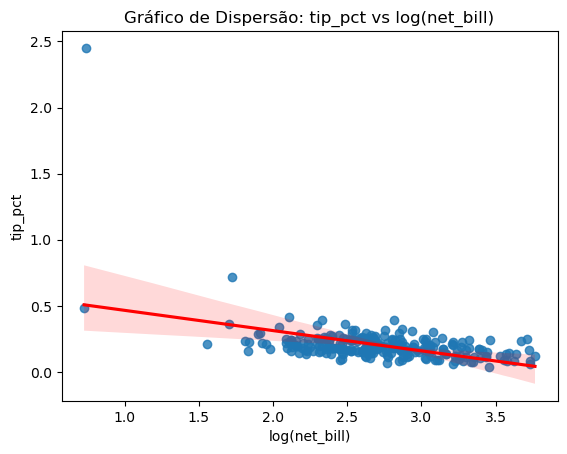

In [7]:
# Adicionar uma nova coluna com o logaritmo de net_bill
tips['log_net_bill'] = np.log(tips['net_bill'])

# Ajustar o modelo de regressão
reg_pct_log = smf.ols('tip_pct ~ log_net_bill', data=tips).fit()

# Exibir o sumário do modelo
print(reg_pct_log.summary())

# Gerar o gráfico de dispersão com o modelo ajustado
sns.regplot(y='tip_pct', x='log_net_bill', data=tips, line_kws={"color":"red"})
plt.title('Gráfico de Dispersão: tip_pct vs log(net_bill)')
plt.xlabel('log(net_bill)')
plt.ylabel('tip_pct')
plt.show()

###  3. ajuste o modelo de ```tip_pct``` em função de um polinômio de segundo grau em ```net_bill```.

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     22.55
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           1.06e-09
Time:                        07:48:01   Log-Likelihood:                 117.25
No. Observations:                 244   AIC:                            -228.5
Df Residuals:                     241   BIC:                            -218.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.4851      0.047     10.332      

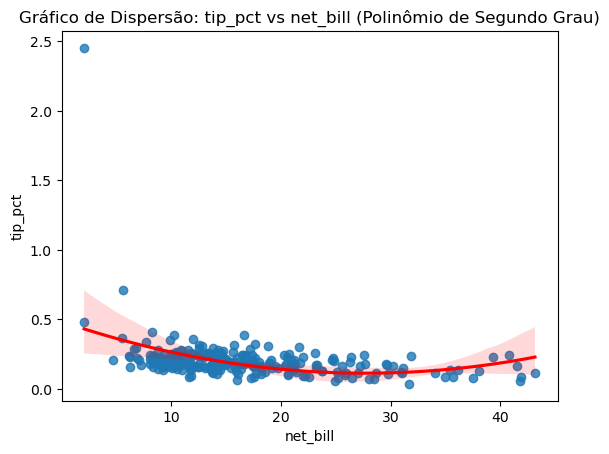

In [9]:
# Adicionar uma nova coluna com o quadrado de net_bill
tips['net_bill_sq'] = tips['net_bill'] ** 2

# Ajustar o modelo de regressão polinomial de segundo grau
reg_pct_poly = smf.ols('tip_pct ~ net_bill + net_bill_sq', data=tips).fit()

# Exibir o sumário do modelo
print(reg_pct_poly.summary())

# Gerar o gráfico de dispersão com o modelo ajustado
sns.regplot(y='tip_pct', x='net_bill', data=tips, order=2, line_kws={"color": "red"})
plt.title('Gráfico de Dispersão: tip_pct vs net_bill (Polinômio de Segundo Grau)')
plt.xlabel('net_bill')
plt.ylabel('tip_pct')
plt.show()

###  4. ajuste um modelo no log do ```tip_pct``` em função de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```

                            OLS Regression Results                            
Dep. Variable:            log_tip_pct   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     74.48
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           8.27e-16
Time:                        07:48:54   Log-Likelihood:                -106.00
No. Observations:                 244   AIC:                             216.0
Df Residuals:                     242   BIC:                             223.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2749      0.056    -22.872      0.0

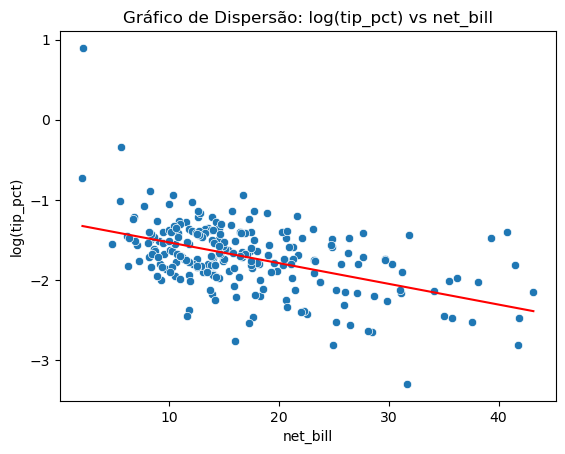

In [11]:
# Adicionar uma coluna com o log do tip_pct
tips['log_tip_pct'] = np.log(tips['tip_pct'])

# Ajustar o modelo de regressão
reg_log_tip = smf.ols('log_tip_pct ~ net_bill', data=tips).fit()

# Exibir o sumário do modelo
print(reg_log_tip.summary())

# Calcular o R² em relação ao tip_pct (valores originais)
r2_tip_pct = 1 - (np.sum((tips['tip_pct'] - np.exp(reg_log_tip.fittedvalues))**2) / 
                  np.sum((tips['tip_pct'] - tips['tip_pct'].mean())**2))

print(f"R² com base em tip_pct original: {r2_tip_pct}")

# Plotar o gráfico de dispersão e linha ajustada
sns.scatterplot(x='net_bill', y='log_tip_pct', data=tips)
sns.lineplot(x=tips['net_bill'], y=reg_log_tip.fittedvalues, color="red")
plt.title('Gráfico de Dispersão: log(tip_pct) vs net_bill')
plt.xlabel('net_bill')
plt.ylabel('log(tip_pct)')
plt.show()

###  5. ajuste um modelo no log do ```tip_pct``` em função do log de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```.

                            OLS Regression Results                            
Dep. Variable:            log_tip_pct   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     100.5
Date:                Wed, 12 Mar 2025   Prob (F-statistic):           5.20e-20
Time:                        07:49:54   Log-Likelihood:                -96.357
No. Observations:                 244   AIC:                             196.7
Df Residuals:                     242   BIC:                             203.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.3942      0.133     -2.961   

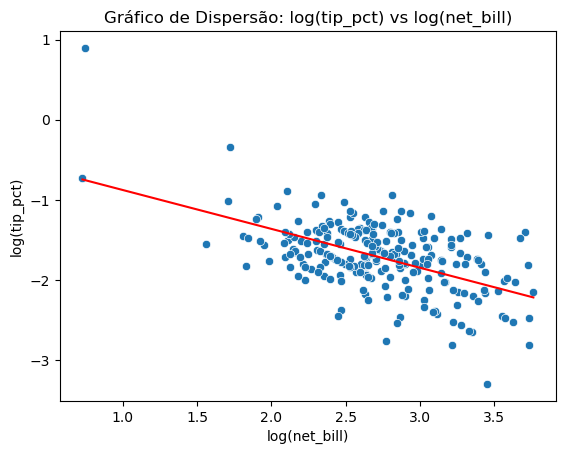

In [13]:
# Criar colunas com o logaritmo de tip_pct e net_bill
tips['log_tip_pct'] = np.log(tips['tip_pct'])
tips['log_net_bill'] = np.log(tips['net_bill'])

# Ajustar o modelo de regressão
reg_log_log = smf.ols('log_tip_pct ~ log_net_bill', data=tips).fit()

# Exibir o sumário do modelo
print(reg_log_log.summary())

# Calcular o R² com base no tip_pct original
r2_tip_pct = 1 - (np.sum((tips['tip_pct'] - np.exp(reg_log_log.fittedvalues))**2) / 
                  np.sum((tips['tip_pct'] - tips['tip_pct'].mean())**2))

print(f"R² com base em tip_pct original: {r2_tip_pct}")

# Gerar gráfico de dispersão com linha de ajuste
sns.scatterplot(x='log_net_bill', y='log_tip_pct', data=tips)
sns.lineplot(x=tips['log_net_bill'], y=reg_log_log.fittedvalues, color="red")
plt.title('Gráfico de Dispersão: log(tip_pct) vs log(net_bill)')
plt.xlabel('log(net_bill)')
plt.ylabel('log(tip_pct)')
plt.show()

###  6. qual modelo resultou no melhor ajuste?

A transformação de x e y em log teve o melhor resultado para o R², apresentando o melhor ajuste do modelo. Entretanto, é importante considerar na hora que for interpretar os valores de y para descrever lembrar que os valores estão em log.